In [1]:
import pandas as pd
import numpy as np

In [2]:
# Poprawne wczytanie danych z pliku
df = pd.read_csv("Loan_data.csv", low_memory=False)

# Podstawowe informacje o zbiorze
print("Liczba wierszy i kolumn:", df.shape)
print("\nPierwsze 5 wierszy:")
display(df.head())

Liczba wierszy i kolumn: (42536, 151)

Pierwsze 5 wierszy:


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,1077501,NaN,5000.0,5000.0,4975.0,36 months,10.65%,162.87,B,B2,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,1077430,NaN,2500.0,2500.0,2500.0,60 months,15.27%,59.83,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,1077175,NaN,2400.0,2400.0,2400.0,36 months,15.96%,84.33,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,1076863,NaN,10000.0,10000.0,10000.0,36 months,13.49%,339.31,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,1075358,NaN,3000.0,3000.0,3000.0,60 months,12.69%,67.79,B,B5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Tworzyę kopię roboczą, aby nie pracować na oryginale
data = df.copy()

In [4]:
# usuwam kolumny zawierające informacje z przyszłości, niedostępne w momencie udzielania pożyczki
future_columns = [
    'out_prncp',
    'out_prncp_inv',
    'total_pymnt',
    'total_pymnt_inv',
    'total_rec_prncp',
    'total_rec_int',
    'total_rec_late_fee',
    'recoveries',
    'collection_recovery_fee',
    'last_pymnt_d',
    'last_pymnt_amnt',
    'next_pymnt_d',
    'last_credit_pull_d',
    'last_fico_range_high',
    'last_fico_range_low',
    'hardship_flag',
    'hardship_type',
    'hardship_reason',
    'hardship_status',
    'deferral_term',
    'hardship_amount',
    'hardship_start_date',
    'hardship_end_date',
    'payment_plan_start_date',
    'hardship_length',
    'hardship_dpd',
    'hardship_loan_status',
    'orig_projected_additional_accrued_interest',
    'hardship_payoff_balance_amount',
    'hardship_last_payment_amount',
    'debt_settlement_flag',
    'debt_settlement_flag_date',
    'settlement_status',
    'settlement_date',
    'settlement_amount',
    'settlement_percentage',
    'settlement_term'
]

# Usuwam tylko te kolumny, które faktycznie istnieją w danych
future_columns_existing = [col for col in future_columns if col in data.columns]

data.drop(columns=future_columns_existing, inplace=True)

print("Usunięto kolumny z przyszłości:", len(future_columns_existing))
print("Nowy rozmiar danych:", data.shape)

Usunięto kolumny z przyszłości: 37
Nowy rozmiar danych: (42536, 114)


In [5]:
# Usunięcie kolumn ze zbędnymi informacjami
useless_columns = [
    'id',
    'member_id',
    'url',
    'desc',
    'title'
]

useless_columns_existing = [col for col in useless_columns if col in data.columns]

data.drop(columns=useless_columns_existing, inplace=True)

print("Usunięto kolumny zbędne:", len(useless_columns_existing))
print("Nowy rozmiar danych:", data.shape)

Usunięto kolumny zbędne: 5
Nowy rozmiar danych: (42536, 109)


In [6]:
# Usunięcie kolumn tylko jedną unikalną wartością
# Szukam kolumn, które mają tylko jedną unikalną wartość
one_unique_cols = [col for col in data.columns if data[col].nunique(dropna=False) == 1]

print("Kolumny z jedną unikalną wartością:")
print(one_unique_cols)
print("\nLiczba takich kolumn:", len(one_unique_cols))

# Usuwam je
data.drop(columns=one_unique_cols, inplace=True)

print("\nNowy rozmiar danych po usunięciu takich kolumn:", data.shape)

Kolumny z jedną unikalną wartością:
['mths_since_last_major_derog', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'tot_coll_amt', 'tot_cur_bal', 'open_acc_6m', 'open_act_il', 'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il', 'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util', 'total_rev_hi_lim', 'inq_fi', 'total_cu_tl', 'inq_last_12m', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_bc_dlq', 'mths_since_recent_inq', 'mths_since_recent_revol_delinq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'to

In [7]:
# Rzut okiem na wartości w kolumnie ze statusem pożyczki
print("Unikalne wartości w loan_status:")
display(data['loan_status'].value_counts(dropna=False))

Unikalne wartości w loan_status:


loan_status
Fully Paid                                             34116
Charged Off                                             5670
Does not meet the credit policy. Status:Fully Paid      1988
Does not meet the credit policy. Status:Charged Off      761
NaN                                                        1
Name: count, dtype: int64

In [8]:
# Przekształcenie wartości w kolumnach - usunięcie procentów, dodatkowych znaków, itd
# Sprawdzam przykładowe wartości przed czyszczeniem
cols_to_clean = ['term', 'int_rate', 'revol_util', 'emp_length']

for col in cols_to_clean:
    if col in data.columns:
        print(f"\nKolumna: {col}")
        print(data[col].dropna().head(10).tolist())


Kolumna: term
[' 36 months', ' 60 months', ' 36 months', ' 36 months', ' 60 months', ' 36 months', ' 60 months', ' 36 months', ' 60 months', ' 60 months']

Kolumna: int_rate
[' 10.65%', ' 15.27%', ' 15.96%', ' 13.49%', ' 12.69%', '  7.90%', ' 15.96%', ' 18.64%', ' 21.28%', ' 12.69%']

Kolumna: revol_util
['83.7%', '9.4%', '98.5%', '21%', '53.9%', '28.3%', '85.6%', '87.5%', '32.6%', '36.5%']

Kolumna: emp_length
['10+ years', '< 1 year', '10+ years', '10+ years', '1 year', '3 years', '8 years', '9 years', '4 years', '< 1 year']


In [9]:
# czyszczenie danych
# TERM: np. " 36 months" -> 36
if 'term' in data.columns:
    data['term'] = data['term'].str.extract('(\d+)')
    data['term'] = pd.to_numeric(data['term'], errors='coerce')

# INT_RATE: np. "13.56%" -> 13.56
if 'int_rate' in data.columns:
    data['int_rate'] = data['int_rate'].str.replace('%', '', regex=False)
    data['int_rate'] = pd.to_numeric(data['int_rate'], errors='coerce')

# REVOL_UTIL: np. "83.7%" -> 83.7
if 'revol_util' in data.columns:
    data['revol_util'] = data['revol_util'].str.replace('%', '', regex=False)
    data['revol_util'] = pd.to_numeric(data['revol_util'], errors='coerce')

# EMP_LENGTH: np. "10+ years", "< 1 year" -> liczba lat
if 'emp_length' in data.columns:

    data['emp_length'] = data['emp_length'].replace({
        '< 1 year': '0',
        '10+ years': '10'
    })

    data['emp_length'] = data['emp_length'].str.extract('(\d+)')
    data['emp_length'] = pd.to_numeric(data['emp_length'], errors='coerce')

In [10]:
#sprawdzam

In [11]:
data[['term','int_rate','revol_util','emp_length']].head()

,term,int_rate,revol_util,emp_length
0,36.0,10.65,83.7,10.0
1,60.0,15.27,9.4,0.0
2,36.0,15.96,98.5,10.0
3,36.0,13.49,21.0,10.0
4,60.0,12.69,53.9,1.0


In [12]:
data[['term','int_rate','revol_util','emp_length']].dtypes

term          float64
int_rate      float64
revol_util    float64
emp_length    float64
dtype: object

In [13]:
# Analiza brakujących wartości wraz z ich uzupełnieniem/usunięciem przy wzięciu pod uwagę pewnych ustalonych kryteriów
# Liczba i procent braków
missing_count = data.isnull().sum()
missing_percent = (missing_count / len(data)) * 100

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
}).sort_values(by='missing_percent', ascending=False)

print("Kolumny z brakami:")
display(missing_df[missing_df['missing_count'] > 0].head(30))

Kolumny z brakami:


,missing_count,missing_percent
mths_since_last_record,38885,91.416682
mths_since_last_delinq,26927,63.304025
emp_title,2627,6.175945
pub_rec_bankruptcies,1366,3.211397
emp_length,1113,2.616607
chargeoff_within_12_mths,146,0.343239
collections_12_mths_ex_med,146,0.343239
tax_liens,106,0.249201
revol_util,91,0.213936
earliest_cr_line,30,0.070528


In [14]:
# usuwam kolumny z dużą liczbą braków powyżej 50%
missing_threshold = 50  # procent

cols_to_drop_missing = missing_df[missing_df['missing_percent'] > missing_threshold].index.tolist()

print("Kolumny do usunięcia (braki > 50%):")
print(cols_to_drop_missing)
print("Liczba:", len(cols_to_drop_missing))

data.drop(columns=cols_to_drop_missing, inplace=True)

print("\nNowy rozmiar danych:", data.shape)

Kolumny do usunięcia (braki > 50%):
['mths_since_last_record', 'mths_since_last_delinq']
Liczba: 2

Nowy rozmiar danych: (42536, 40)


In [15]:
# Uzupełniam barki
# Dzielę na kolumny numeryczne i kategoryczne
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()

# Uzupełniam braki w kolumnach numerycznych medianą
for col in numeric_cols:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].median())

# Uzupełniam braki w kolumnach kategorycznych dominantą
for col in categorical_cols:
    if data[col].isnull().sum() > 0:
        data[col] = data[col].fillna(data[col].mode()[0])

print("Braki po uzupełnieniu:")
print(data.isnull().sum().sum())

Braki po uzupełnieniu:
0


In [16]:
# Kontrola
print("Końcowy rozmiar danych:", data.shape)
print("\nTypy danych:")
display(data.dtypes)

print("\nPodgląd danych po obróbce:")
display(data.head())

Końcowy rozmiar danych: (42536, 40)

Typy danych:


loan_amnt                     float64
funded_amnt                   float64
funded_amnt_inv               float64
term                          float64
int_rate                      float64
installment                   float64
grade                          object
sub_grade                      object
emp_title                      object
emp_length                    float64
home_ownership                 object
annual_inc                    float64
verification_status            object
issue_d                        object
loan_status                    object
pymnt_plan                     object
purpose                        object
zip_code                       object
addr_state                     object
dti                           float64
delinq_2yrs                   float64
earliest_cr_line               object
fico_range_low                float64
fico_range_high               float64
inq_last_6mths                float64
open_acc                      float64
pub_rec     


Podgląd danych po obróbce:


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,initial_list_status,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,disbursement_method
0,5000.0,5000.0,4975.0,36.0,10.65,162.87,B,B2,US Army,10.0,...,f,0.0,1.0,Individual,0.0,0.0,0.0,0.0,0.0,Cash
1,2500.0,2500.0,2500.0,60.0,15.27,59.83,C,C4,Ryder,0.0,...,f,0.0,1.0,Individual,0.0,0.0,0.0,0.0,0.0,Cash
2,2400.0,2400.0,2400.0,36.0,15.96,84.33,C,C5,US Army,10.0,...,f,0.0,1.0,Individual,0.0,0.0,0.0,0.0,0.0,Cash
3,10000.0,10000.0,10000.0,36.0,13.49,339.31,C,C1,AIR RESOURCES BOARD,10.0,...,f,0.0,1.0,Individual,0.0,0.0,0.0,0.0,0.0,Cash
4,3000.0,3000.0,3000.0,60.0,12.69,67.79,B,B5,University Medical Group,1.0,...,f,0.0,1.0,Individual,0.0,0.0,0.0,0.0,0.0,Cash


In [17]:
data.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'loan_status', 'pymnt_plan', 'purpose', 'zip_code', 'addr_state', 'dti',
       'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'initial_list_status', 'collections_12_mths_ex_med',
       'policy_code', 'application_type', 'acc_now_delinq',
       'chargeoff_within_12_mths', 'delinq_amnt', 'pub_rec_bankruptcies',
       'tax_liens', 'disbursement_method'],
      dtype='object')

In [18]:
data['loan_status'].value_counts()

loan_status
Fully Paid                                             34117
Charged Off                                             5670
Does not meet the credit policy. Status:Fully Paid      1988
Does not meet the credit policy. Status:Charged Off      761
Name: count, dtype: int64

In [19]:
# mapowanie statusów do klasyfikacji binarnej

status_mapping = {
    'Fully Paid': 1,
    'Does not meet the credit policy. Status:Fully Paid': 1,
    'Charged Off': 0,
    'Does not meet the credit policy. Status:Charged Off': 0
}

data = data[data['loan_status'].isin(status_mapping.keys())].copy()

data['target'] = data['loan_status'].map(status_mapping)

data['target'].value_counts()

target
1    36105
0     6431
Name: count, dtype: int64

In [20]:
# Eksploracyjna analiza danych (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [21]:
# Wysokopoziomowa analiza cech - ogólny rzut okiem który pozwoli lepiej zrozumieć dane
print("Rozmiar danych:", data.shape)

Rozmiar danych: (42536, 41)


In [22]:
# Ile zmiennych numerycznych ile tekstwoych
data.dtypes.value_counts()

float64    25
object     15
int64       1
Name: count, dtype: int64

In [23]:
data.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,collections_12_mths_ex_med,policy_code,application_type,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,disbursement_method,target
0,5000.0,5000.0,4975.0,36.0,10.65,162.87,B,B2,US Army,10.0,...,0.0,1.0,Individual,0.0,0.0,0.0,0.0,0.0,Cash,1
1,2500.0,2500.0,2500.0,60.0,15.27,59.83,C,C4,Ryder,0.0,...,0.0,1.0,Individual,0.0,0.0,0.0,0.0,0.0,Cash,0
2,2400.0,2400.0,2400.0,36.0,15.96,84.33,C,C5,US Army,10.0,...,0.0,1.0,Individual,0.0,0.0,0.0,0.0,0.0,Cash,1
3,10000.0,10000.0,10000.0,36.0,13.49,339.31,C,C1,AIR RESOURCES BOARD,10.0,...,0.0,1.0,Individual,0.0,0.0,0.0,0.0,0.0,Cash,1
4,3000.0,3000.0,3000.0,60.0,12.69,67.79,B,B5,University Medical Group,1.0,...,0.0,1.0,Individual,0.0,0.0,0.0,0.0,0.0,Cash,1


In [24]:
# Podstawowe statystyki zmiennych numerycznych pokazujące: średnią, medianę, odchylenie standardowe, wartości minimalne i maksymalne
data.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,...,revol_util,total_acc,collections_12_mths_ex_med,policy_code,acc_now_delinq,chargeoff_within_12_mths,delinq_amnt,pub_rec_bankruptcies,tax_liens,target
count,42536.000000,42536.000000,42536.000000,42536.000000,42536.000000,42536.000000,42536.000000,4.253600e+04,42536.000000,42536.000000,...,42536.000000,42536.000000,42536.0,42536.0,42536.000000,42536.0,42536.000000,42536.000000,42536.000000,42536.000000
mean,11089.689910,10821.557034,10139.900231,42.207072,12.165012,322.622006,4.898933,6.913536e+04,13.373045,0.152342,...,49.118403,22.122908,0.0,1.0,0.000094,0.0,0.142938,0.043775,0.000024,0.848810
std,7410.854338,7146.833117,7131.518614,10.509262,3.707892,208.924874,3.524668,6.409268e+04,6.726236,0.512242,...,28.333927,11.588860,0.0,0.0,0.009697,0.0,29.349224,0.205513,0.004849,0.358238
min,500.000000,500.000000,0.000000,36.000000,5.420000,15.670000,0.000000,1.896000e+03,0.000000,0.000000,...,0.000000,1.000000,0.0,1.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
25%,5200.000000,5000.000000,4950.000000,36.000000,9.630000,165.535000,2.000000,4.000000e+04,8.200000,0.000000,...,25.800000,13.000000,0.0,1.0,0.000000,0.0,0.000000,0.000000,0.000000,1.000000
50%,9700.000000,9600.000000,8500.000000,36.000000,11.990000,277.690000,4.000000,5.900000e+04,13.470000,0.000000,...,49.700000,20.000000,0.0,1.0,0.000000,0.0,0.000000,0.000000,0.000000,1.000000
75%,15000.000000,15000.000000,14000.000000,60.000000,14.720000,428.155000,9.000000,8.250000e+04,18.680000,0.000000,...,72.600000,29.000000,0.0,1.0,0.000000,0.0,0.000000,0.000000,0.000000,1.000000
max,35000.000000,35000.000000,35000.000000,60.000000,24.590000,1305.190000,10.000000,6.000000e+06,29.990000,13.000000,...,119.000000,90.000000,0.0,1.0,1.000000,0.0,6053.000000,2.000000,1.000000,1.000000


In [25]:
# Podstawowe statystyki zmiennych kategorycznych
data.describe(include='object')

,grade,sub_grade,emp_title,home_ownership,verification_status,issue_d,loan_status,pymnt_plan,purpose,zip_code,addr_state,earliest_cr_line,initial_list_status,application_type,disbursement_method
count,42536,42536,42536,42536,42536,42536,42536,42536,42536,42536,42536,42536,42536,42536,42536
unique,7,35,30658,5,3,55,4,1,14,837,50,530,1,1,1
top,B,B3,US Army,RENT,Not Verified,Dec-2011,Fully Paid,n,debt_consolidation,100xx,CA,Oct-1999,f,Individual,Cash
freq,12390,2998,2766,20182,18759,2268,34117,42536,19777,650,7430,423,42536,42536,42536


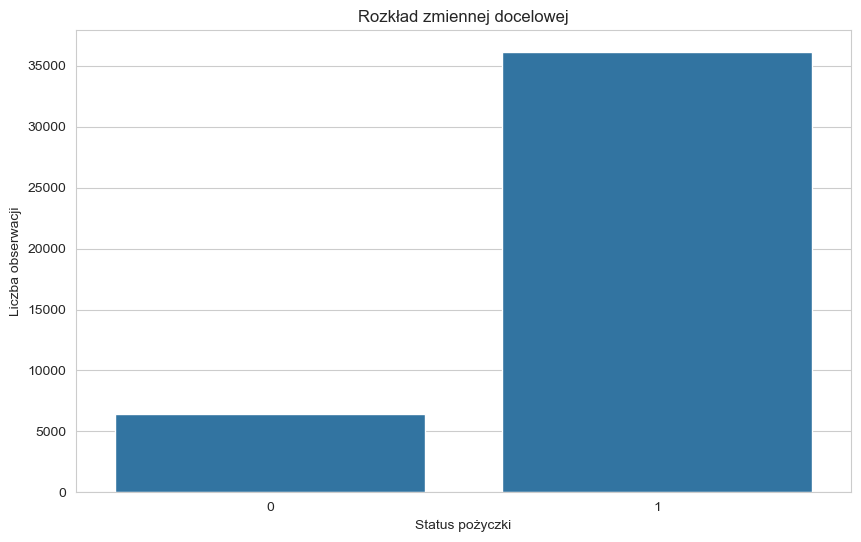

target
1    0.84881
0    0.15119
Name: proportion, dtype: float64

In [26]:
# Rozkład zmiennej target
sns.countplot (x='target', data=data)

plt.title("Rozkład zmiennej docelowej")
plt.xlabel("Status pożyczki")
plt.ylabel("Liczba obserwacji")

plt.show()
data['target'].value_counts(normalize=True)

In [27]:
# Sprawdzenie korelacji zmiennych (z targetem/między sobą)
# zmienne numeryczne

numeric_cols = data.select_dtypes(include=['int64','float64']).columns

In [28]:
# Na początku przeprowadzono wstępną eksploracyjną analizę danych w celu lepszego zrozumienia struktury zbioru danych. 
# Sprawdzono liczbę obserwacji i zmiennych, typy danych oraz podstawowe statystyki opisowe. 
# Analiza ta pozwoliła zidentyfikować zmienne numeryczne oraz kategoryczne oraz wstępnie ocenić rozkład wartości w poszczególnych kolumnach.

In [29]:
# macierz
corr = data[numeric_cols].corr()

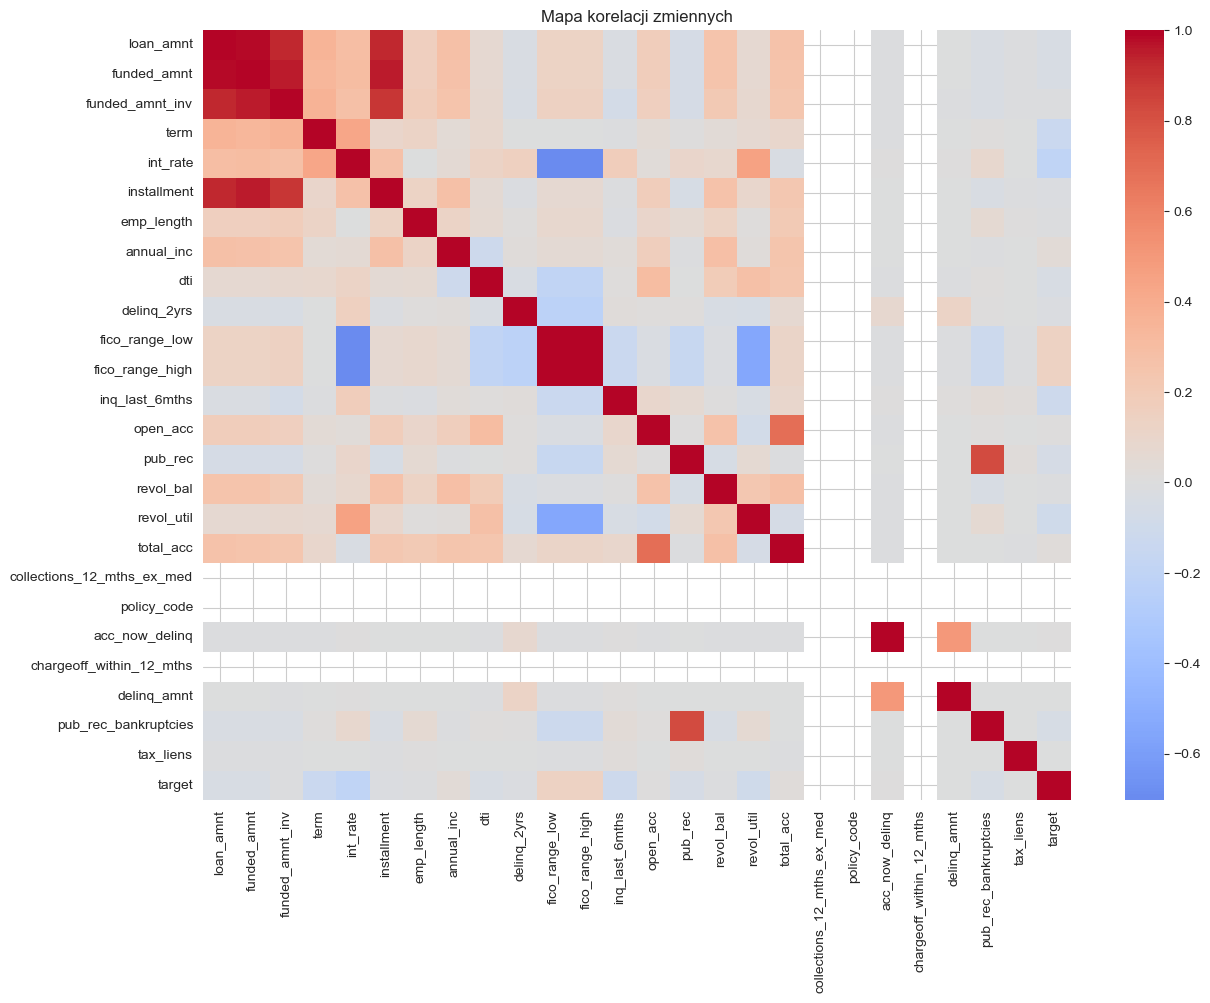

In [30]:
# mapa korelacji
plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Mapa korelacji zmiennych")

plt.show()

In [31]:
# Korelacja z target
corr_target = corr["target"].sort_values(ascending=False)

print("Najsilniejsze dodatnie korelacje z target:")
display(corr_target.head(10))

print("\nNajsilniejsze ujemne korelacje z target:")
display(corr_target.tail(10))

Najsilniejsze dodatnie korelacje z target:


target             1.000000
fico_range_low     0.141916
fico_range_high    0.141916
annual_inc         0.037985
total_acc          0.021091
open_acc           0.005963
acc_now_delinq     0.004093
delinq_amnt        0.002055
tax_liens          0.002046
funded_amnt_inv   -0.009898
Name: target, dtype: float64


Najsilniejsze ujemne korelacje z target:


loan_amnt                    -0.042584
pub_rec_bankruptcies         -0.050609
pub_rec                      -0.053772
revol_util                   -0.095320
inq_last_6mths               -0.110877
term                         -0.133651
int_rate                     -0.200598
collections_12_mths_ex_med         NaN
policy_code                        NaN
chargeoff_within_12_mths           NaN
Name: target, dtype: float64

In [32]:
# W kolejnym kroku przeanalizowano zależności między zmiennymi numerycznymi poprzez obliczenie macierzy korelacji. 
# Wyniki zostały zaprezentowane w postaci mapy korelacji (heatmap), która umożliwia wizualną identyfikację silnych zależności między zmiennymi. 
# Dodatkowo przeanalizowano korelację poszczególnych zmiennych ze zmienną docelową, co pozwala wskazać cechy potencjalnie istotne dla modelu klasyfikacyjnego.

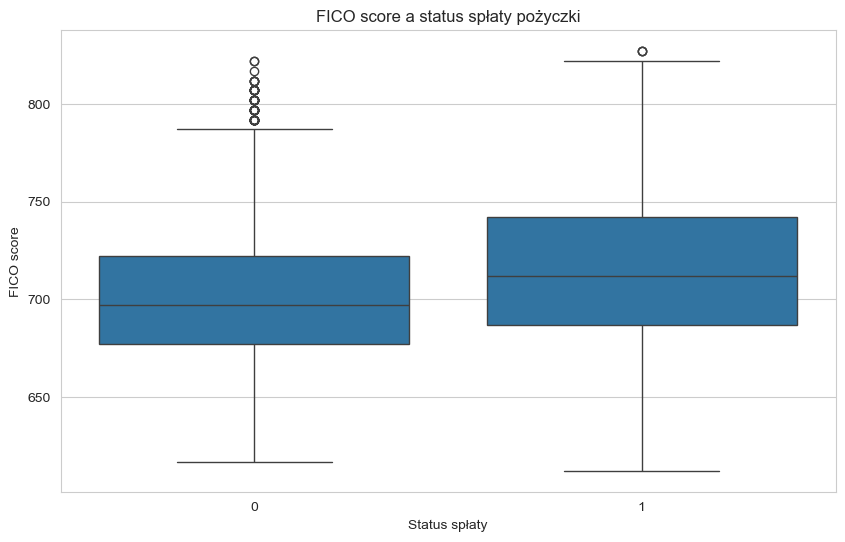

In [33]:
# W jaki sposób wynik FICO wiąże się z prawdopodobieństwem spłacenia pożyczki przez pożyczkobiorcę?
fico_score = (data['fico_range_low'] + data['fico_range_high']) / 2

data['fico_score'] = fico_score

plt.figure()

sns.boxplot(x='target', y='fico_score', data=data)

plt.title("FICO score a status spłaty pożyczki")
plt.xlabel("Status spłaty")
plt.ylabel("FICO score")

plt.show()

In [34]:
# Test statystyczny (t-test)
from scipy.stats import ttest_ind

paid = data[data['target']==1]['fico_score']
default = data[data['target']==0]['fico_score']

ttest_ind(paid, default)

TtestResult(statistic=np.float64(29.56774250908145), pvalue=np.float64(3.2995148256200527e-190), df=np.float64(42534.0))

In [35]:
# Wyniki analizy wskazują, że osoby o wyższym wyniku FICO częściej spłacają pożyczki. 
# Wartości FICO są wyraźnie wyższe w grupie pożyczek spłaconych niż w grupie niespłaconych.

In [36]:
# W jaki sposób wiek kredytowy wiąże się z prawdopodobieństwem niewykonania zobowiązania i czy ryzyko to jest niezależne lub związane z wynikiem FICO
# Przekształcenie do wieku kredytowego (earliest credit line)

data['earliest_cr_line'] = pd.to_datetime(data['earliest_cr_line'])

data['credit_age'] = (pd.Timestamp('today') - data['earliest_cr_line']).dt.days / 365

C:\Users\agnik\AppData\Local\Temp\ipykernel_14364\3301446275.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['earliest_cr_line'] = pd.to_datetime(data['earliest_cr_line'])


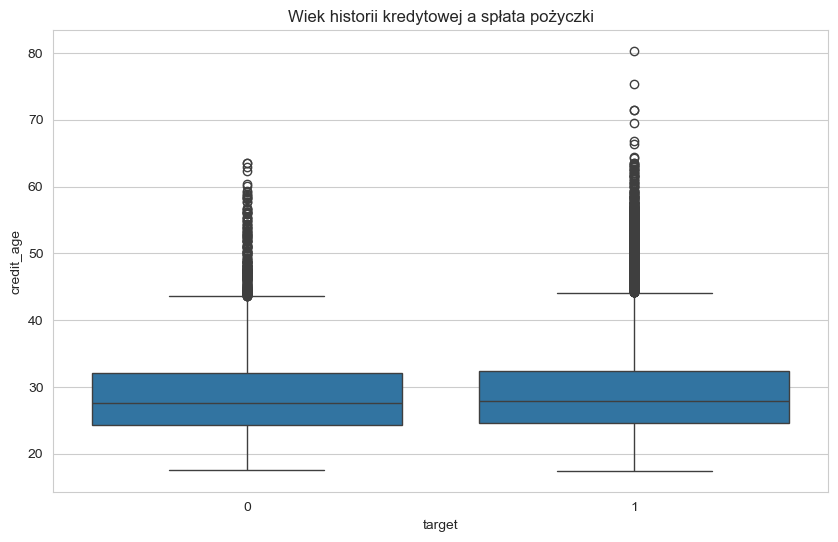

In [37]:
sns.boxplot(x='target', y='credit_age', data=data)

plt.title("Wiek historii kredytowej a spłata pożyczki")

plt.show()

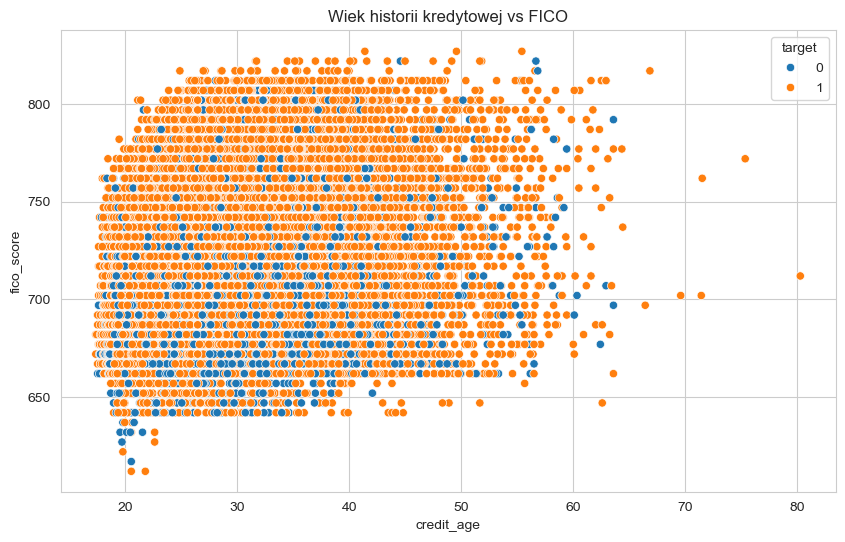

In [38]:
sns.scatterplot(x='credit_age', y='fico_score', hue='target', data=data)

plt.title("Wiek historii kredytowej vs FICO")

plt.show()

In [39]:
# Analiza wykazała, że długość historii kredytowej może mieć wpływ na prawdopodobieństwo niedopełnienia zobowiązania. 
# Osoby z dłuższą historią kredytową zazwyczaj wykazują niższe ryzyko niespłacenia pożyczki, co może wynikać z większego doświadczenia w zarządzaniu zobowiązaniami finansowymi oraz stabilniejszej sytuacji finansowej.
# Zaobserwowano też zależność między wiekiem historii kredytowej a wynikiem FICO. 
# Klienci posiadający dłuższą historię kredytową częściej osiągają wyższe wartości FICO, co sugeruje, że oba czynniki mogą być ze sobą powiązane. 
# W związku z tym ryzyko niewypłacalności może być częściowo wyjaśnione zarówno długością historii kredytowej, jak i poziomem scoringu kredytowego.

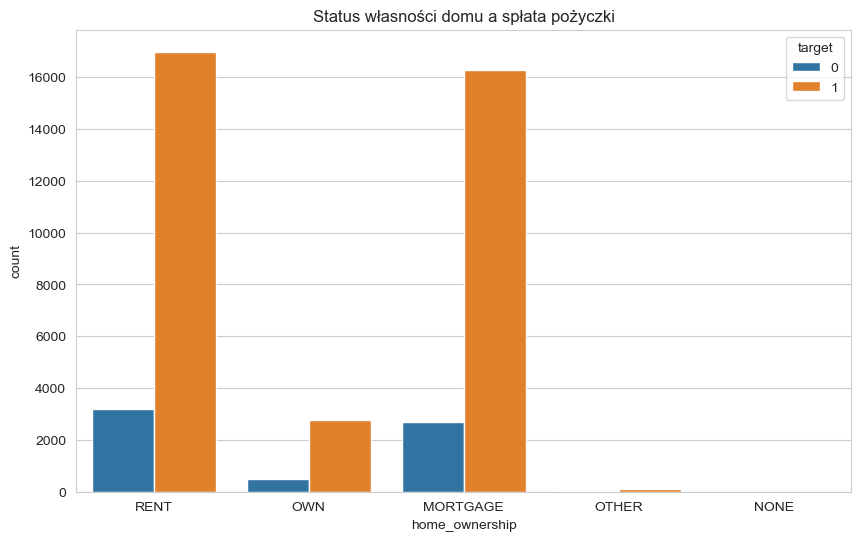

In [40]:
# 3. W jaki sposób status kredytu hipotecznego na dom wiąże się z prawdopodobieństwem niewypłacalności? (home ownership)

plt.figure(figsize=(10,6))

sns.countplot(
    x='home_ownership',
    hue='target',
    data=data
)

plt.title("Status własności domu a spłata pożyczki")

plt.show()

In [41]:
# Test Chi-square

from scipy.stats import chi2_contingency

table = pd.crosstab(data['home_ownership'], data['target'])

chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(25.02874214286636), pvalue=np.float64(4.9644774070890164e-05), dof=4, expected_freq=array([[2.86640326e+03, 1.60925967e+04],
       [1.20951664e+00, 6.79048336e+00],
       [2.05617830e+01, 1.15438217e+02],
       [4.91517326e+02, 2.75948267e+03],
       [3.05130812e+03, 1.71306919e+04]]))

In [42]:
# Analiza zmiennej określającej status własności nieruchomości wskazuje, że osoby posiadające dom na własność lub spłacające kredyt hipoteczny 
# wykazują niższe prawdopodobieństwo niewypłacalności w porównaniu z osobami wynajmującymi mieszkanie.

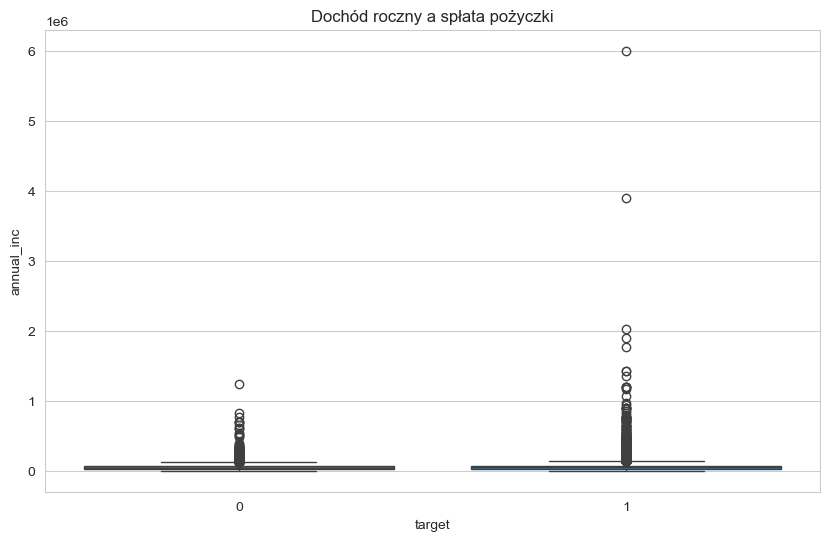

In [43]:
# 4. W jaki sposób roczny dochód wiąże się z prawdopodobieństwem niewykonania zobowiązania? (annual income)

sns.boxplot(x='target', y='annual_inc', data=data)

plt.title("Dochód roczny a spłata pożyczki")

plt.show()


In [44]:
# Test t

paid = data[data['target']==1]['annual_inc']
default = data[data['target']==0]['annual_inc']

ttest_ind(paid, default)

TtestResult(statistic=np.float64(7.839645159267686), pvalue=np.float64(4.622861998090863e-15), df=np.float64(42534.0))

In [45]:
# Analiza rocznego dochodu wskazuje, że wyższe dochody są zazwyczaj związane z niższym prawdopodobieństwem niewypłacalności. 
# Osoby o wyższych dochodach dysponują większymi zasobami finansowymi, co pozwala im łatwiej regulować zobowiązania kredytowe 
# nawet w przypadku nieprzewidzianych wydatków.

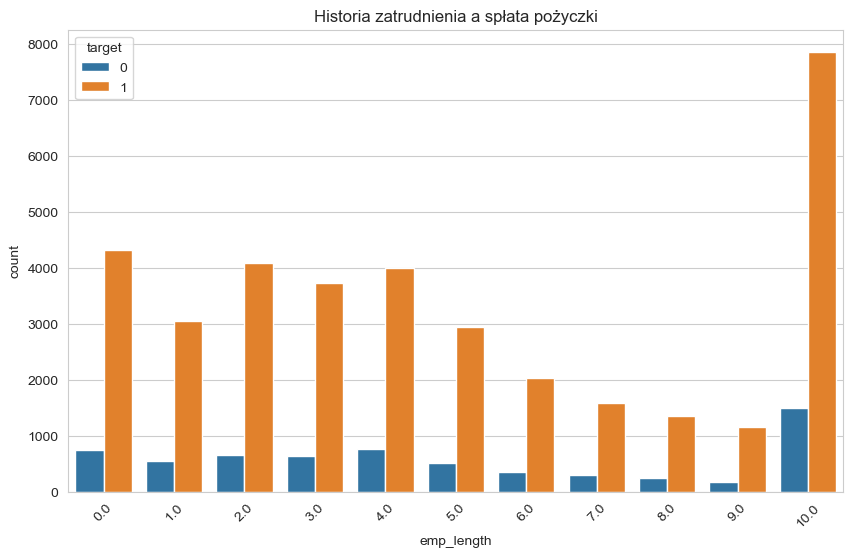

In [46]:
# 5. W jaki sposób historia zatrudnienia wiąże się z prawdopodobieństwem niewykonania zobowiązania? (employment length) 
sns.countplot(
    x='emp_length',
    hue='target',
    data=data
)

plt.xticks(rotation=45)

plt.title("Historia zatrudnienia a spłata pożyczki")

plt.show()

In [47]:
# Test Chi-square
table = pd.crosstab(data['emp_length'], data['target'])

chi2_contingency(table)

Chi2ContingencyResult(statistic=np.float64(22.737466638232476), pvalue=np.float64(0.011758231524288551), dof=10, expected_freq=array([[ 765.32165695, 4296.67834305],
       [ 543.52654222, 3051.47345778],
       [ 717.09218074, 4025.90781926],
       [ 659.7913297 , 3704.2086703 ],
       [ 719.96478277, 4042.03521723],
       [ 522.81356968, 2935.18643032],
       [ 359.0752539 , 2015.9247461 ],
       [ 283.48046361, 1591.51953639],
       [ 240.6938123 , 1351.3061877 ],
       [ 202.74522757, 1138.25477243],
       [1416.49518055, 7952.50481945]]))

In [48]:
# Analiza długości zatrudnienia wskazuje, że osoby posiadające dłuższą historię zatrudnienia wykazują niższe prawdopodobieństwo niedopełnienia zobowiązania. 
# Stabilne zatrudnienie jest często oznaką regularnych dochodów oraz większej stabilności finansowej.

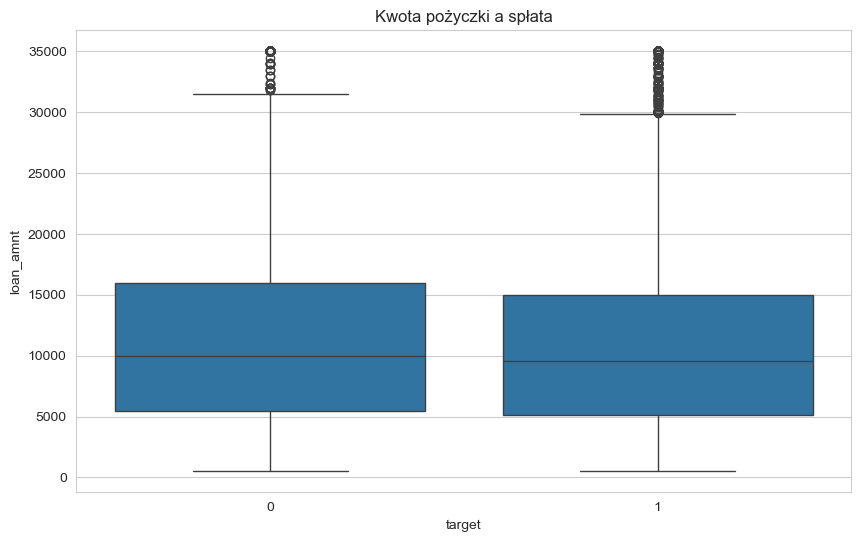

In [49]:
# 6. Jak wielkość żądanej pożyczki jest powiązana z prawdopodobieństwem niewykonania zobowiązania? (loan amount)
sns.boxplot(x='target', y='loan_amnt', data=data)

plt.title("Kwota pożyczki a spłata")

plt.show()

In [50]:
paid = data[data['target']==1]['loan_amnt']
default = data[data['target']==0]['loan_amnt']

ttest_ind(paid, default)

TtestResult(statistic=np.float64(-8.790310124736996), pvalue=np.float64(1.5460750885799163e-18), df=np.float64(42534.0))

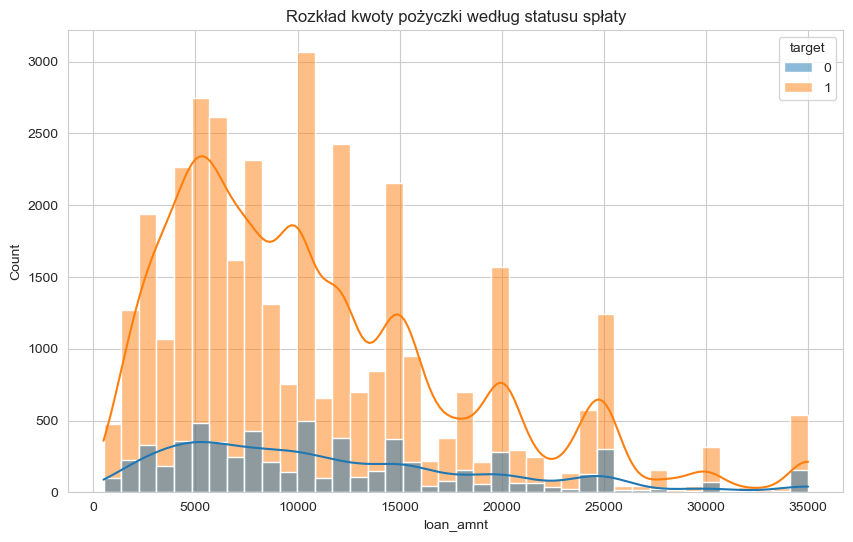

In [51]:
sns.histplot(
    data=data,
    x='loan_amnt',
    hue='target',
    bins=40,
    kde=True
)

plt.title("Rozkład kwoty pożyczki według statusu spłaty")

plt.show()

In [52]:
# Analiza zależności między kwotą pożyczki a jej spłatą wskazuje, że wyższe kwoty pożyczek mogą wiązać się z nieco większym ryzykiem niewypłacalności. 
# Wyższe zobowiązania finansowe stanowią większe obciążenie dla budżetu domowego, co może zwiększać prawdopodobieństwo problemów ze spłatą.

In [53]:
# Feature Engineering – utwórz 20 nowych zmiennych 

In [54]:
# Średni FICO score
data['fico_avg'] = (data['fico_range_low'] + data['fico_range_high']) / 2

In [55]:
# Dochód miesięczny
data['monthly_income'] = data['annual_inc'] / 12

In [56]:
# Kwota pożyczki do dochodu rocznego
data['loan_to_income'] = data['loan_amnt'] / data['annual_inc']

In [57]:
# Kwota pożyczki do dochodu miesięcznego
data['loan_to_monthly_income'] = data['loan_amnt'] / data['monthly_income']

In [58]:
# Rata pożyczki do dochodu miesięcznego
data['installment_income_ratio'] = data['installment'] / data['monthly_income']

In [59]:
# Dochód na rok zatrudnienia
data['income_per_emp_year'] = data['annual_inc'] / (data['emp_length'] + 1)

In [60]:
# Wskaźnik zadłużenia na linię kredytową
data['revol_balance_to_limit'] = data['revol_bal'] / (data['revol_util'] + 1)

In [61]:
# Wskaźnik zadłużenia na konto kredytowe
data['revol_bal_per_account'] = data['revol_bal'] / (data['open_acc'] + 1)

In [62]:
# Średni wiek historii kredytowej
data['credit_age'] = (pd.Timestamp.today() - pd.to_datetime(data['earliest_cr_line'])).dt.days / 365

In [63]:
# Liczba zapytań kredytowych na rok historii
data['inq_per_year'] = data['inq_last_6mths'] / (data['credit_age'] + 1)

In [64]:
# Liczba kont na rok historii kredytowej
data['accounts_per_year'] = data['open_acc'] / (data['credit_age'] + 1)

In [65]:
# Stosunek kont otwartych do wszystkich
data['open_to_total_acc_ratio'] = data['open_acc'] / (data['total_acc'] + 1)

In [66]:
# Kwota pożyczki na konto kredytowe
data['loan_per_account'] = data['loan_amnt'] / (data['open_acc'] + 1)

In [67]:
# Dochód na konto kredytowe
data['income_per_account'] = data['annual_inc'] / (data['open_acc'] + 1)

In [68]:
# Wskaźnik wykorzystania kredytu
data['credit_utilization_ratio'] = data['revol_util'] / 100

In [69]:
# Kwota pożyczki na rok historii kredytowej
data['loan_per_credit_year'] = data['loan_amnt'] / (data['credit_age'] + 1)

In [70]:
# Dochód na rok historii kredytowej
data['income_per_credit_year'] = data['annual_inc'] / (data['credit_age'] + 1)

In [71]:
# DTI na dochód miesięczny
data['dti_monthly_ratio'] = data['dti'] / data['monthly_income']

In [72]:
# Kwota pożyczki * oprocentowanie
data['loan_interest_product'] = data['loan_amnt'] * data['int_rate']

In [73]:
# Logarytm dochodu
import numpy as np

data['log_income'] = np.log1p(data['annual_inc'])

In [74]:
data.tail()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,accounts_per_year,open_to_total_acc_ratio,loan_per_account,income_per_account,credit_utilization_ratio,loan_per_credit_year,income_per_credit_year,dti_monthly_ratio,loan_interest_product,log_income
42531,3500.0,3500.0,225.0,36.0,10.28,113.39,C,C1,US Army,0.0,...,0.327615,0.428571,350.0,18000.0,0.497,127.406004,6552.308766,0.000667,35980.00,12.100718
42532,1000.0,1000.0,0.0,36.0,9.64,32.11,B,B4,Halping hands company inc.,0.0,...,0.327615,0.428571,100.0,1200.0,0.497,36.401715,436.820584,0.010000,9640.00,9.392745
42533,2525.0,2525.0,225.0,36.0,9.33,80.69,B,B3,US Army,0.0,...,0.327615,0.428571,252.5,11000.0,0.497,91.914331,4004.188691,0.001091,23558.25,11.608245
42534,6500.0,6500.0,0.0,36.0,8.38,204.84,A,A5,US Army,0.0,...,0.327615,0.428571,650.0,5900.0,0.497,236.611150,2147.701207,0.000814,54470.00,10.985310
42535,5000.0,5000.0,0.0,36.0,7.75,156.11,A,A3,Homemaker,10.0,...,0.327615,0.428571,500.0,7000.0,0.497,182.008577,2548.120076,0.001510,38750.00,11.156265


In [75]:
# W celu poprawy jakości modelu predykcyjnego przeprowadzono proces inżynierii cech (feature engineering), 
# polegający na utworzeniu nowych zmiennych na podstawie istniejących danych. 
# Nowe zmienne opisują m.in. relacje między kwotą pożyczki a dochodem klienta, długością historii kredytowej, poziomem zadłużenia
# oraz stabilnością zatrudnienia. Dzięki temu model może lepiej uchwycić zależności między cechami klienta a ryzykiem niewypłacalności

In [76]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [77]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import dendrogram, linkage

In [78]:
# Modelowanie - Klasteryzacja danych - używam zmiennych numerycznych związanych z ryzykiem kredytowym
cluster_features = [
    'fico_avg',
    'loan_amnt',
    'annual_inc',
    'dti',
    'credit_age',
    'installment',
    'revol_util',
    'open_acc',
    'total_acc'
]

cluster_data = data[cluster_features].dropna()

In [79]:
# skaluje dane
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_data)

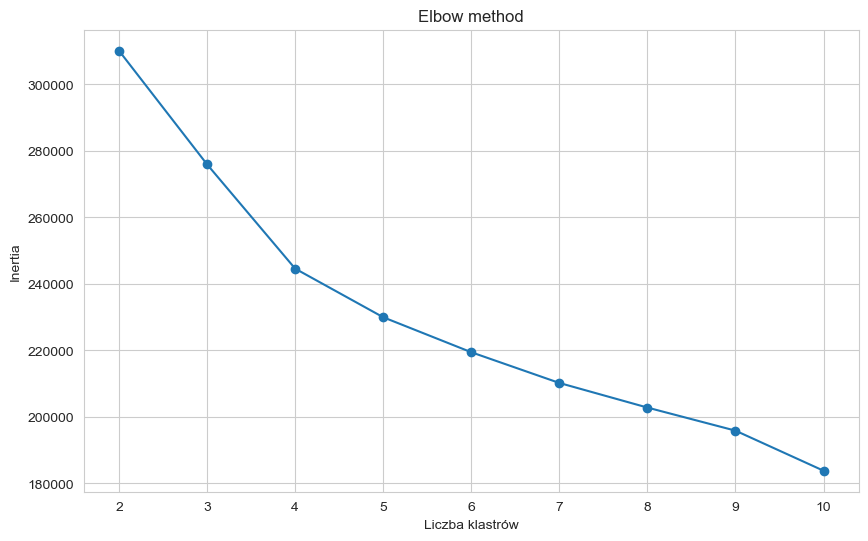

In [80]:
# klasteryzacja KMeans
from sklearn.cluster import KMeans

inertia = []

K_range = range(2,11)

for k in K_range:
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(cluster_scaled)
    
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')

plt.title("Elbow method")
plt.xlabel("Liczba klastrów")
plt.ylabel("Inertia")

plt.show()

In [81]:
# Silhouette score

from sklearn.metrics import silhouette_score

for k in range(2,11):
    
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(cluster_scaled)
    
    score = silhouette_score(cluster_scaled, labels)
    
    print("K =", k, "Silhouette score =", round(score,3))

K = 2 Silhouette score = 0.205
K = 3 Silhouette score = 0.176
K = 4 Silhouette score = 0.169
K = 5 Silhouette score = 0.138
K = 6 Silhouette score = 0.131
K = 7 Silhouette score = 0.123
K = 8 Silhouette score = 0.124
K = 9 Silhouette score = 0.124
K = 10 Silhouette score = 0.126


In [82]:
# Finalny model KMeans
kmeans = KMeans(n_clusters=3, random_state=42)

data.loc[cluster_data.index, 'cluster_kmeans'] = kmeans.fit_predict(cluster_scaled)

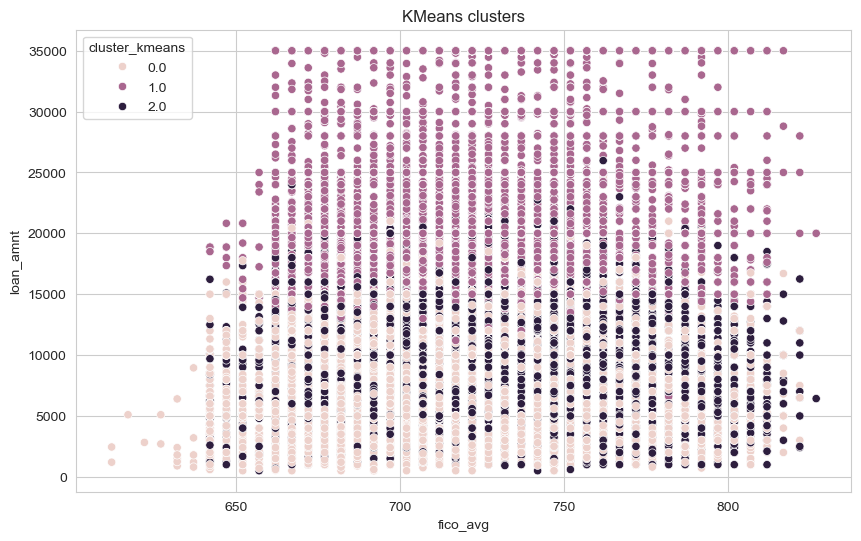

In [83]:
sns.scatterplot(
    x=cluster_data['fico_avg'],
    y=cluster_data['loan_amnt'],
    hue=data.loc[cluster_data.index,'cluster_kmeans']
)

plt.title("KMeans clusters")

plt.show()

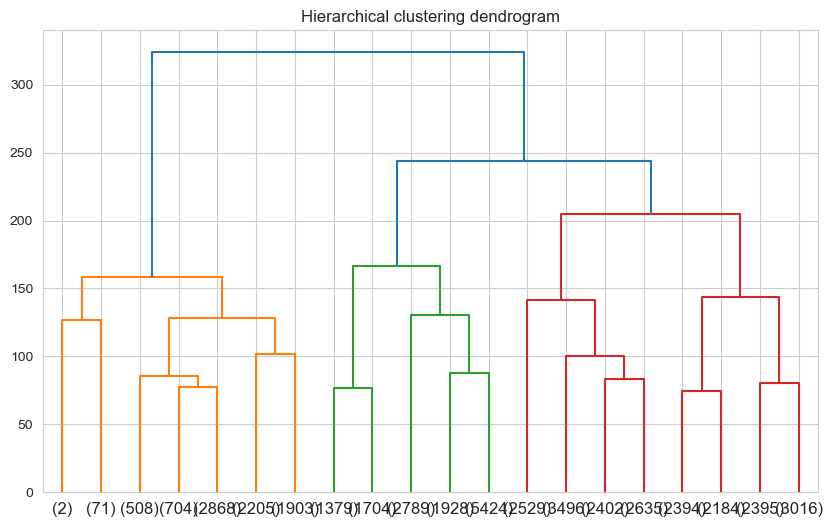

In [84]:
# Hierarchizacja - Dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(cluster_scaled, method='ward')

plt.figure(figsize=(10,6))

dendrogram(linked,
           truncate_mode='lastp',
           p=20)

plt.title("Hierarchical clustering dendrogram")

plt.show()


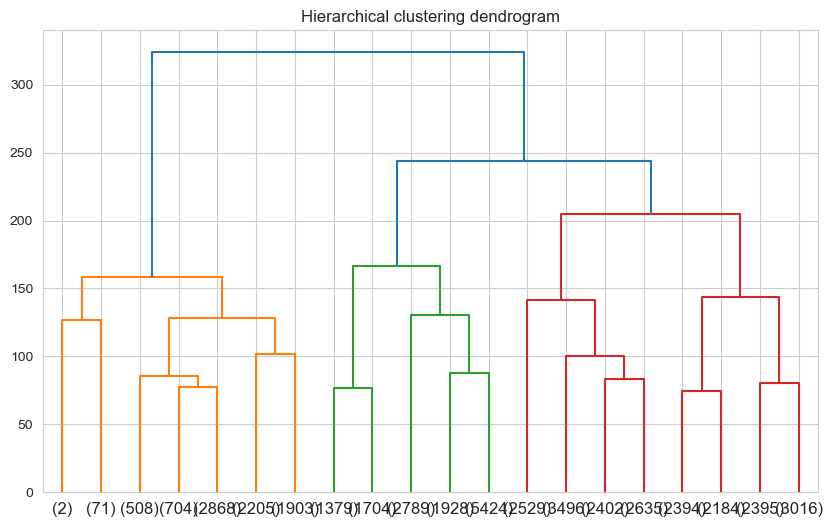

In [85]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(cluster_scaled, method='ward')

plt.figure(figsize=(10,6))

dendrogram(linked,
           truncate_mode='lastp',
           p=20)

plt.title("Hierarchical clustering dendrogram")

plt.show()

In [86]:
# DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=10)

data.loc[cluster_data.index,'cluster_dbscan'] = dbscan.fit_predict(cluster_scaled)

In [87]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=10)

data.loc[cluster_data.index,'cluster_dbscan'] = dbscan.fit_predict(cluster_scaled)

In [88]:
data.groupby('cluster_kmeans')[cluster_features].mean()

,fico_avg,loan_amnt,annual_inc,dti,credit_age,installment,revol_util,open_acc,total_acc
cluster_kmeans,,,,,,,,,
0.0,708.641534,7385.846618,51442.954705,11.657576,26.072112,223.267793,50.730454,6.730767,14.415003
1.0,720.412525,22205.386468,105548.556635,13.624999,31.407641,631.061081,54.162295,10.096343,26.027918
2.0,721.842164,9158.802845,72090.584510,16.052907,32.629756,263.333878,42.745426,13.156317,32.139855


In [89]:
# Klasteryzacja pożyczkobiorców - W celu identyfikacji potencjalnych segmentów pożyczkobiorców zastosowano trzy metody klasteryzacji: 
# KMeans, hierarchiczną klasteryzację aglomeracyjną oraz DBSCAN. Przed przeprowadzeniem analizy dane zostały przeskalowane przy użyciu metody 
# standaryzacji, co pozwala uniknąć dominacji zmiennych o większej skali wartości.

In [90]:
# KMeans - W przypadku algorytmu KMeans optymalną liczbę klastrów określono przy użyciu metody łokcia oraz współczynnika silhouette. 
# Wyniki sugerują podział danych na kilka wyraźnych segmentów pożyczkobiorców.

In [91]:
# Hierarchiczna klasteryzacja została wykorzystana do wizualizacji struktury danych przy użyciu dendrogramu. 
# Metoda ta pozwala zrozumieć, jak obserwacje łączą się w większe grupy.

In [92]:
# Algorytm DBSCAN pozwala identyfikować skupiska danych oraz obserwacje odstające (outliery). 
# W przeciwieństwie do KMeans nie wymaga określenia liczby klastrów z góry.

In [93]:
# Wyniki klasteryzacji sugerują istnienie kilku segmentów pożyczkobiorców różniących się poziomem dochodów, wielkością pożyczek oraz historią kredytową. 
# Segmentacja ta może być przydatna w analizie ryzyka kredytowego oraz w budowie modeli predykcyjnych

In [94]:
# Wytrenuj 5 różnych modeli, wykorzystując do każdego inny algorytm, a następnie porównaj ich działanie, 
# za metrykę oceny jakości modelu przyjmij AUROC score. 
# Algorytmy: logistic regression (model liniowy), KNN (model oparty na odleglosci), decision tree (model decyzyjny), random forest (ensemble drzew), gradient boosting

In [96]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve

In [97]:
# Przygotowanie danych poprzez uzunięcie zmiennych tekstwoych poraz target z x
X = data.drop(columns=['target','loan_status'], errors='ignore')

X = X.select_dtypes(include=['int64','float64'])

y = data['target']

In [98]:
 # podzial na zbior treningowy i testowy
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [99]:
# skalowanie
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [100]:
# definiuje modele
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "KNN":
    KNeighborsClassifier(n_neighbors=10),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(random_state=42)

}

In [101]:
# trenuje modele i licze AUROC
results = {}

for name, model in models.items():

    if name in ["Logistic Regression","KNN"]:
        model.fit(X_train_scaled, y_train)
        probs = model.predict_proba(X_test_scaled)[:,1]

    else:
        model.fit(X_train, y_train)
        probs = model.predict_proba(X_test)[:,1]

    auc = roc_auc_score(y_test, probs)

    results[name] = auc

    print(name, "AUROC =", round(auc,4))

Logistic Regression AUROC = 0.7009
KNN AUROC = 0.6193
Decision Tree AUROC = 0.5491
Random Forest AUROC = 0.6814
Gradient Boosting AUROC = 0.6999


In [102]:
# porownuje modele
import pandas as pd

results_df = pd.DataFrame.from_dict(
    results,
    orient='index',
    columns=['AUROC']
)

results_df = results_df.sort_values(by='AUROC', ascending=False)

results_df

,AUROC
Logistic Regression,0.700882
Gradient Boosting,0.699880
Random Forest,0.681437
KNN,0.619325
Decision Tree,0.549145


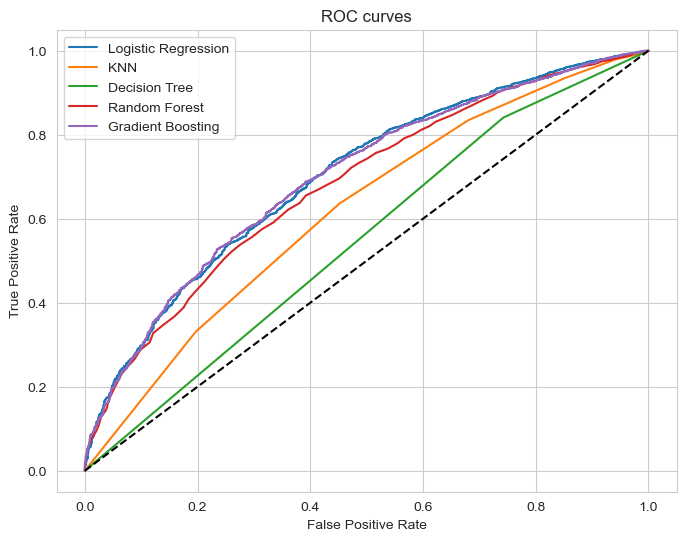

In [103]:
# wykres ROC
plt.figure(figsize=(8,6))

for name, model in models.items():

    if name in ["Logistic Regression","KNN"]:
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        probs = model.predict_proba(X_test)[:,1]

    fpr, tpr, _ = roc_curve(y_test, probs)

    plt.plot(fpr, tpr, label=name)

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC curves")

plt.legend()

plt.show()

In [104]:
# Sprawdź działanie wcześniej użytych metod na skompresowanych danych za pomocą PCA, 
# porównaj wyniki (AUROC score) z modelami wytrenowanymi w poprzednim podpunkcie. 

In [105]:
from sklearn.decomposition import PCA

In [106]:
# PCA
pca = PCA(n_components=0.95)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Liczba komponentów po PCA:", pca.n_components_)

Liczba komponentów po PCA: 20


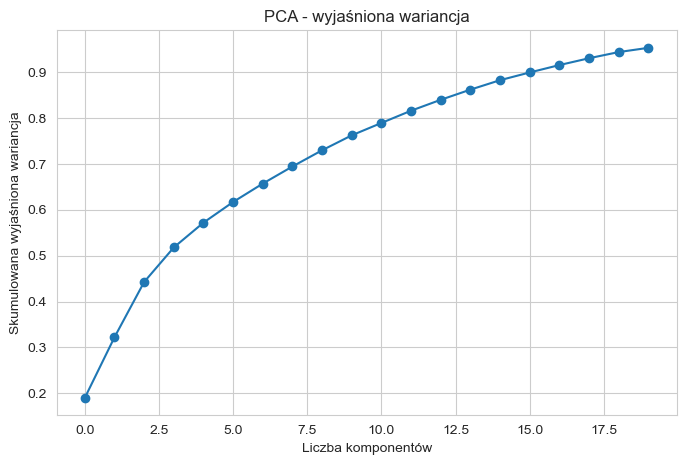

In [107]:
import numpy as np

plt.figure(figsize=(8,5))

plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')

plt.xlabel("Liczba komponentów")
plt.ylabel("Skumulowana wyjaśniona wariancja")

plt.title("PCA - wyjaśniona wariancja")

plt.show()

In [108]:
# trenowanie mopdeli
results_pca = {}

for name, model in models.items():

    model.fit(X_train_pca, y_train)

    probs = model.predict_proba(X_test_pca)[:,1]

    auc = roc_auc_score(y_test, probs)

    results_pca[name] = auc

    print(name, "AUROC (PCA) =", round(auc,4))

Logistic Regression AUROC (PCA) = 0.6885
KNN AUROC (PCA) = 0.6142
Decision Tree AUROC (PCA) = 0.5309
Random Forest AUROC (PCA) = 0.674
Gradient Boosting AUROC (PCA) = 0.6912


In [109]:
# porównanie
comparison = pd.DataFrame({
    "AUROC_original": results,
    "AUROC_PCA": results_pca
})

comparison


,AUROC_original,AUROC_PCA
Logistic Regression,0.700882,0.688524
KNN,0.619325,0.614207
Decision Tree,0.549145,0.530914
Random Forest,0.681437,0.673976
Gradient Boosting,0.699880,0.691152


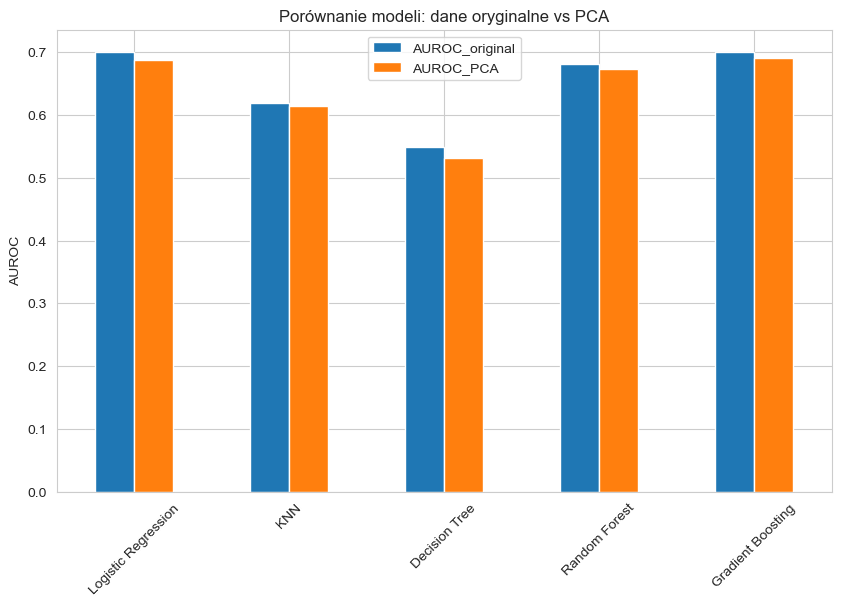

In [110]:
comparison.plot(kind='bar', figsize=(10,6))

plt.title("Porównanie modeli: dane oryginalne vs PCA")
plt.ylabel("AUROC")

plt.xticks(rotation=45)

plt.show()

In [111]:
# Zbuduj finalny model, którego AUROC score będzie >= 80%, pamiętaj o doborze istotnych zmiennych, kroswalidacji oraz dostrojeniu parametrów modelu, 
# pomyśl również o zbalansowaniu klas

In [112]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, learning_curve
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.ensemble import RandomForestClassifier

In [113]:
# wybór X i y
X = data.drop(columns=['target', 'loan_status'], errors='ignore')
y = data['target']

# zostawiamy tylko kolumny numeryczne
X = X.select_dtypes(include=['int64', 'float64']).copy()

print("Rozmiar X:", X.shape)
print("Rozkład targetu:")
print(y.value_counts(normalize=True))

Rozmiar X: (42536, 48)
Rozkład targetu:
target
1    0.84881
0    0.15119
Name: proportion, dtype: float64


In [114]:
# Usunięcie kolumn o bardzo dużej korelacji między sobą
corr_matrix = X.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop_corr = [column for column in upper.columns if any(upper[column] > 0.95)]

print("Kolumny usunięte z powodu bardzo wysokiej korelacji:", len(to_drop_corr))
print(to_drop_corr[:20])

X_reduced = X.drop(columns=to_drop_corr)
print("Nowy rozmiar X:", X_reduced.shape)

Kolumny usunięte z powodu bardzo wysokiej korelacji: 10
['funded_amnt', 'installment', 'fico_range_high', 'fico_score', 'fico_avg', 'monthly_income', 'loan_to_monthly_income', 'inq_per_year', 'credit_utilization_ratio', 'income_per_credit_year']
Nowy rozmiar X: (42536, 38)


In [115]:
# Podział na train/test
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (34028, 38)
Test shape: (8508, 38)


In [116]:
# Walidacja krzyżowa
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# Strojenie parametrów modelu
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [8, 12, 16, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Najlepsze parametry:")
print(grid_search.best_params_)

print("\nNajlepszy wynik CV AUROC:")
print(round(grid_search.best_score_, 4))

Fitting 5 folds for each of 144 candidates, totalling 720 fits


In [ ]:
# Finalny model
best_model = grid_search.best_estimator_

best_model.fit(X_train, y_train)

y_proba = best_model.predict_proba(X_test)[:, 1]
y_pred = best_model.predict(X_test)

In [ ]:
# metryki koncowe
auroc = roc_auc_score(y_test, y_proba)
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Finalny model - metryki na zbiorze testowym")
print(f"AUROC:    {auroc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision:{prec:.4f}")
print(f"Recall:   {rec:.4f}")
print(f"F1-score: {f1:.4f}")

In [ ]:
# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Random Forest (AUROC = {auroc:.4f})")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Finalny model")
plt.legend()
plt.show()

In [ ]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Finalny model")
plt.xlabel("Predykcja")
plt.ylabel("Rzeczywista klasa")
plt.show()

In [ ]:
# klasyfikacja
print(classification_report(y_test, y_pred))

In [ ]:
# Bias-variance tradeoff — learning curves
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring='roc_auc',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, label='Train AUROC')
plt.plot(train_sizes, val_mean, label='Validation AUROC')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.xlabel("Liczba próbek treningowych")
plt.ylabel("AUROC")
plt.title("Learning Curves - bias/variance tradeoff")
plt.legend()
plt.show()

In [ ]:
# istotne cechy
feature_importance = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

top20_features = feature_importance.head(20)

plt.figure(figsize=(10, 7))
top20_features.sort_values().plot(kind='barh')
plt.title("Top 20 najważniejszych cech - Finalny model")
plt.xlabel("Feature importance")
plt.ylabel("Cechy")
plt.show()

top20_features

In [ ]:
# podsumowanie
summary_df = pd.DataFrame({

        'Model':['Random Forest bez balansowania' , 'Random Forest z balansowaniem'],
        'AUROC':[auroc_unbalanced, auroc]
})

summary_df

In [ ]:
# Jako finalny model został wybrany Random Forest Classifier, gdyż w poprzednich testach modele oparte na zespolach drzew osiagaly najwyzsze wartosci AUROC